## Counting the CNOTs

### CI configuration

In [1]:
from NSMFermions.hamiltonian_utils import FermiHubbardHamiltonian
from NSMFermions.nuclear_physics_utils import (
    get_twobody_nuclearshell_model,
    SingleParticleState,
)
import scipy

from scipy.sparse import lil_matrix

file_name = "data/usdb.nat"

SPS = SingleParticleState(file_name=file_name)


nparts = [(2, 2)]
titles = [r"$^{20}$Ne"]


size_a = SPS.energies.shape[0] // 2
size_b = SPS.energies.shape[0] // 2

title = r"$^{20}$Ne"

/home/ecosta/miniconda3/envs/qiskit_nature_4_fermions/lib/python3.14/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
twobody_matrix, energies = get_twobody_nuclearshell_model(file_name=file_name)

Computing the matrix, pls wait... (u_u) 



100%|██████████| 24/24 [00:14<00:00,  1.62it/s]


In [6]:
from openfermion import FermionOperator, jordan_wigner, count_qubits
from openfermion.utils import count_qubits
from collections import Counter
import numpy as np

# --- Costruisci H_CI come FermionOperator ---
hamiltonian = FermionOperator()

# One-body terms: e_a * c†_a c_a
for a, e_a in enumerate(SPS.energies[:]):
    hamiltonian += FermionOperator(f"{a}^ {a}", e_a)

# Two-body terms: (1/4) * v_abcd * c†_a c†_b c_d c_c
for (a, b, c, d), v_abcd in twobody_matrix.items():

    hamiltonian += FermionOperator(f"{a}^ {b}^ {d} {c}", 0.25 * v_abcd)

# --- Jordan-Wigner ---
qubit_op = jordan_wigner(hamiltonian)

# --- Pauli weight e CNOT count ---
weights = []
cnot_counts = []

for pauli_term, coeff in qubit_op.terms.items():
    if abs(coeff) < 1e-10:  # salta termini numericamente zero
        continue

    weight = len(
        pauli_term
    )  # in openfermion pauli_term è una tupla di (qubit, 'X'/'Y'/'Z')
    weights.append(weight)

    cnot = 2 * (weight - 1) if weight > 1 else 0
    cnot_counts.append(cnot)

weights = np.array(weights)
cnot_counts = np.array(cnot_counts)

# --- Risultati ---
n_qubits = count_qubits(qubit_op)
print(f"Numero di qubit:          {n_qubits}")
print(f"Numero di Pauli strings:  {len(weights)}")
print(f"Pauli weight medio:       {weights.mean():.2f}")
print(f"Pauli weight massimo:     {weights.max()}")
print(f"CNOT totali:              {cnot_counts.sum()}")
print()
print("Distribuzione Pauli weights:")
for w, count in sorted(Counter(weights).items()):
    print(
        f"  weight {w:2d}: {count:4d} stringhe  → {2*(w-1) if w>1 else 0} CNOT ciascuna"
    )

tot_cnots_ci = cnot_counts.sum()
print(tot_cnots_ci)
tot_pauli_strings_ci = len(weights)

Numero di qubit:          24
Numero di Pauli strings:  12869
Pauli weight medio:       9.06
Pauli weight massimo:     24
CNOT totali:              207512

Distribuzione Pauli weights:
  weight  0:    1 stringhe  → 0 CNOT ciascuna
  weight  1:   24 stringhe  → 0 CNOT ciascuna
  weight  2:  276 stringhe  → 2 CNOT ciascuna
  weight  3:   12 stringhe  → 4 CNOT ciascuna
  weight  4: 1192 stringhe  → 6 CNOT ciascuna
  weight  5:  860 stringhe  → 8 CNOT ciascuna
  weight  6: 1600 stringhe  → 10 CNOT ciascuna
  weight  7:  880 stringhe  → 12 CNOT ciascuna
  weight  8:  856 stringhe  → 14 CNOT ciascuna
  weight  9: 2320 stringhe  → 16 CNOT ciascuna
  weight 10:  704 stringhe  → 18 CNOT ciascuna
  weight 11:  896 stringhe  → 20 CNOT ciascuna
  weight 12:  680 stringhe  → 22 CNOT ciascuna
  weight 13:  960 stringhe  → 24 CNOT ciascuna
  weight 14:  288 stringhe  → 26 CNOT ciascuna
  weight 15:  256 stringhe  → 28 CNOT ciascuna
  weight 16:  664 stringhe  → 30 CNOT ciascuna
  weight 17:  128 strin

#### Quasiparticle Hamiltonian

In [7]:
data = np.load("data/matrix_elements_h_eff_2body/one_body_nn_sd.npz")
g_ab_one = {}
for key, value in zip(data["keys"], data["values"]):

    g_ab_one[(key[0], key[1])] = value

data = np.load("data/matrix_elements_h_eff_2body/one_body_nn_sd.npz")
g_ab_two = {}
for key, value in zip(data["keys"], data["values"]):

    g_ab_two[(key[0], key[1])] = value

print(g_ab_one, g_ab_two)

{(np.int64(0), np.int64(0)): np.float64(-9.3151), (np.int64(0), np.int64(1)): np.float64(0.6897999999999996), (np.int64(0), np.int64(2)): np.float64(-0.4062999999999996), (np.int64(0), np.int64(3)): np.float64(-0.900781889989654), (np.int64(0), np.int64(4)): np.float64(-1.9314456782406446), (np.int64(0), np.int64(5)): np.float64(0.6017349640876247), (np.int64(1), np.int64(0)): np.float64(0.6897999999999996), (np.int64(1), np.int64(1)): np.float64(-8.8615), (np.int64(1), np.int64(2)): np.float64(0.8598999999999998), (np.int64(1), np.int64(3)): np.float64(0.900781889989654), (np.int64(1), np.int64(4)): np.float64(1.1336192497488327), (np.int64(1), np.int64(5)): np.float64(-1.3995613925794368), (np.int64(2), np.int64(0)): np.float64(-0.4062999999999996), (np.int64(2), np.int64(1)): np.float64(0.8598999999999998), (np.int64(2), np.int64(2)): np.float64(-9.145), (np.int64(2), np.int64(3)): np.float64(-0.900781889989654), (np.int64(2), np.int64(4)): np.float64(-0.7347060355029268), (np.int64

In [8]:
from collections import Counter
import numpy as np


def analyze_hqp(coeffs_dict, mode="XY", label=""):
    """
    mode='XY' : S+S- + h.c. → X_A X_B + Y_A Y_B
    mode='NN' : N_A N_B     → -Z_A/4 - Z_B/4 + Z_A Z_B/4  (+ costante ignorata)
    """
    pauli_list = []

    for (A, B), coeff in coeffs_dict.items():
        if abs(coeff) < 1e-10:
            continue

        if A == B:
            # N_A → -Z_A/2 + costante
            pauli_list.append(
                {"string": f"Z_{A}", "coeff": -coeff / 2, "weight": 1, "cnot": 0}
            )

        else:
            if mode == "XY":
                pauli_list.append(
                    {"string": f"X_{A} X_{B}", "coeff": coeff, "weight": 2, "cnot": 2}
                )
                pauli_list.append(
                    {"string": f"Y_{A} Y_{B}", "coeff": coeff, "weight": 2, "cnot": 2}
                )

            elif mode == "NN":
                pauli_list.append(
                    {"string": f"Z_{A}", "coeff": -coeff / 4, "weight": 1, "cnot": 0}
                )
                pauli_list.append(
                    {"string": f"Z_{B}", "coeff": -coeff / 4, "weight": 1, "cnot": 0}
                )
                pauli_list.append(
                    {
                        "string": f"Z_{A} Z_{B}",
                        "coeff": coeff / 4,
                        "weight": 2,
                        "cnot": 2,
                    }
                )
                # termine I: coeff/4 * I → costante, ignorata

    weights = np.array([p["weight"] for p in pauli_list])
    cnots = np.array([p["cnot"] for p in pauli_list])

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Pauli strings : {len(pauli_list)}")
    print(f"Weight medio  : {weights.mean():.2f}")
    print(f"Weight max    : {weights.max()}")
    print(f"CNOT totali   : {cnots.sum()}")

    return pauli_list, weights, cnots


# --- Esegui sui tuoi dizionari ---
# (incolla qui i tuoi dict per protoni e neutroni)

pauli_protons, w_p, c_p = analyze_hqp(g_ab_one, label="H_QP — Protons", mode="XY")
pauli_neutrons, w_n, c_n = analyze_hqp(g_ab_two, label="H_QP — Neutrons", mode="XY")

# --- Sommario totale H_QP ---
print(f"\n{'='*45}")
print(f"  TOTALE H_QP (protons + neutrons)")
print(f"{'='*45}")
all_weights = np.concatenate([w_p, w_n])
all_cnots = np.concatenate([c_p, c_n])
print(f"Pauli strings totali : {len(all_weights)}")
print(f"CNOT totali          : {all_cnots.sum()}")

cnot_q = all_cnots.sum()
pauli_strings_q = len(all_weights)


  H_QP — Protons
Pauli strings : 66
Weight medio  : 1.91
Weight max    : 2
CNOT totali   : 120

  H_QP — Neutrons
Pauli strings : 66
Weight medio  : 1.91
Weight max    : 2
CNOT totali   : 120

  TOTALE H_QP (protons + neutrons)
Pauli strings totali : 132
CNOT totali          : 240


In [9]:
# --- Esegui sui tuoi dizionari ---
# (incolla qui i tuoi dict per protoni e neutroni)

pauli_interaction, w_int, c_int = analyze_hqp(
    g_ab_two, label="H_QP — Protons", mode="NN"
)


# --- Sommario totale H_QP ---
print(f"\n{'='*45}")
print(f"  TOTALE H_QP (protons + neutrons)")
print(f"{'='*45}")
all_weights = np.concatenate([w_int])
all_cnots = np.concatenate([c_int])
print(f"Pauli strings totali : {len(all_weights)}")
print(f"CNOT totali          : {all_cnots.sum()}")
cnot_q += all_cnots.sum()
pauli_strings_q += len(all_weights)


  H_QP — Protons
Pauli strings : 96
Weight medio  : 1.31
Weight max    : 2
CNOT totali   : 60

  TOTALE H_QP (protons + neutrons)
Pauli strings totali : 96
CNOT totali          : 60


#### Adding the BW correction

In [10]:
import pickle

with open("approximations_as_dictionary_bwi.pkl", "rb") as f:
    bw_dict = pickle.load(f)

print(bw_dict[0, 6, 0, 6])

9.853044056400865e+154


In [11]:
def expand_single_term(A, B, C, D, coeff):
    """
    Espande S+_A S+_B S-_C S-_D
    Il dizionario contiene già h.c., quindi:
    - le parti immaginarie si cancellano
    - restano solo le parti reali
    """
    terms = []

    # --- CASO 1: A=C, B=D → N_A N_B ---
    if A == C and B == D:
        terms.append({"string": f"Z_{A}", "coeff": -coeff / 4, "weight": 1, "cnot": 0})
        terms.append({"string": f"Z_{B}", "coeff": -coeff / 4, "weight": 1, "cnot": 0})
        terms.append(
            {"string": f"Z_{A} Z_{B}", "coeff": coeff / 4, "weight": 2, "cnot": 2}
        )

    # --- CASO 2: A=C, B≠D → N_A * S+_B S-_D ---
    # h.c. cancella XY e YX, restano solo XX e YY
    elif A == C and B != D:
        terms.append(
            {"string": f"X_{B} X_{D}", "coeff": coeff / 4, "weight": 2, "cnot": 2}
        )
        terms.append(
            {"string": f"Y_{B} Y_{D}", "coeff": coeff / 4, "weight": 2, "cnot": 2}
        )
        terms.append(
            {
                "string": f"Z_{A} X_{B} X_{D}",
                "coeff": -coeff / 4,
                "weight": 3,
                "cnot": 4,
            }
        )
        terms.append(
            {
                "string": f"Z_{A} Y_{B} Y_{D}",
                "coeff": -coeff / 4,
                "weight": 3,
                "cnot": 4,
            }
        )

    # --- CASO 3: A≠C, B=D → S+_A S-_C * N_B ---
    # h.c. cancella XY e YX, restano solo XX e YY
    elif A != C and B == D:
        terms.append(
            {"string": f"X_{A} X_{C}", "coeff": coeff / 4, "weight": 2, "cnot": 2}
        )
        terms.append(
            {"string": f"Y_{A} Y_{C}", "coeff": coeff / 4, "weight": 2, "cnot": 2}
        )
        terms.append(
            {
                "string": f"X_{A} X_{C} Z_{B}",
                "coeff": -coeff / 4,
                "weight": 3,
                "cnot": 4,
            }
        )
        terms.append(
            {
                "string": f"Y_{A} Y_{C} Z_{B}",
                "coeff": -coeff / 4,
                "weight": 3,
                "cnot": 4,
            }
        )

    # --- CASO 4: A≠C, B≠D → caso generale ---
    # Delle 16 Pauli, 8 immaginarie si cancellano con h.c.
    # Restano 8 reali con segni alternati
    else:
        real_paulis = [
            ("X", "X", "X", "X", +1),
            ("X", "X", "Y", "Y", -1),
            ("X", "Y", "Y", "X", +1),
            ("X", "Y", "X", "Y", -1),
            ("Y", "X", "X", "Y", +1),  # nota: h.c. di XY è YX
            ("Y", "X", "Y", "X", -1),
            ("Y", "Y", "X", "X", -1),
            ("Y", "Y", "Y", "Y", +1),
        ]
        for pA, pB, pC, pD, sign in real_paulis:
            terms.append(
                {
                    "string": f"{pA}_{A} {pB}_{B} {pC}_{C} {pD}_{D}",
                    "coeff": sign * coeff / 4,
                    "weight": 4,
                    "cnot": 6,
                }
            )

    return terms


def analyze_bw_corrections(bw_dict, label="H_BW corrections"):
    pauli_list = []
    case_counts = {1: 0, 2: 0, 3: 0, 4: 0}

    for (A, B, C, D), coeff in bw_dict.items():
        if abs(coeff) < 1e-10:
            continue

        if A == C and B == D:
            case_counts[1] += 1
        elif A == C and B != D:
            case_counts[2] += 1
        elif A != C and B == D:
            case_counts[3] += 1
        else:
            case_counts[4] += 1

        pauli_list.extend(expand_single_term(A, B, C, D, coeff))

    weights = np.array([p["weight"] for p in pauli_list])
    cnots = np.array([p["cnot"] for p in pauli_list])

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"Elementi totali nel dict    : {len(bw_dict)}")
    print(f"  Caso 1 (A=C, B=D)        : {case_counts[1]:4d}  →  3 Pauli  (weight ≤ 2)")
    print(f"  Caso 2 (A=C, B≠D)        : {case_counts[2]:4d}  →  4 Pauli  (weight 2-3)")
    print(f"  Caso 3 (A≠C, B=D)        : {case_counts[3]:4d}  →  4 Pauli  (weight 2-3)")
    print(f"  Caso 4 (A≠C, B≠D)        : {case_counts[4]:4d}  →  8 Pauli  (weight 4)")
    print(f"{'='*55}")
    print(f"Pauli strings totali        : {len(pauli_list)}")
    print(f"CNOT totali                 : {int(cnots.sum())}")
    print()
    print("Distribuzione Pauli weights:")
    for w, count in sorted(Counter(weights).items()):
        cnot_per = 2 * (w - 1) if w > 1 else 0
        print(f"  weight {w}: {count:5d} stringhe  →  {cnot_per} CNOT ciascuna")

    return pauli_list, weights, cnots


# --- Uso ---
pauli_bw, w_bw, c_bw = analyze_bw_corrections(bw_dict, label="H_BW — S+S+S-S-")

cnots_bw = cnot_q + c_bw.sum()
pauli_strings_bw = pauli_strings_q + len(w_bw)


  H_BW — S+S+S-S-
Elementi totali nel dict    : 1296
  Caso 1 (A=C, B=D)        :   36  →  3 Pauli  (weight ≤ 2)
  Caso 2 (A=C, B≠D)        :  180  →  4 Pauli  (weight 2-3)
  Caso 3 (A≠C, B=D)        :  180  →  4 Pauli  (weight 2-3)
  Caso 4 (A≠C, B≠D)        :  900  →  8 Pauli  (weight 4)
Pauli strings totali        : 8748
CNOT totali                 : 47592

Distribuzione Pauli weights:
  weight 1:    72 stringhe  →  0 CNOT ciascuna
  weight 2:   756 stringhe  →  2 CNOT ciascuna
  weight 3:   720 stringhe  →  4 CNOT ciascuna
  weight 4:  7200 stringhe  →  6 CNOT ciascuna


In [12]:
# Controlla quante coppie (ABCD) e (DCBA) sono entrambe presenti
duplicates = 0
for A, B, C, D in bw_dict:
    if (D, C, B, A) in bw_dict:
        duplicates += 1

print(f"Coppie con h.c. esplicito: {duplicates} / {len(bw_dict)}")
print(f"Elementi unici (senza h.c.): {(len(bw_dict) - duplicates) + duplicates//2}")

Coppie con h.c. esplicito: 0 / 1296
Elementi unici (senza h.c.): 1296


207512 300 47892
12869 228 8976


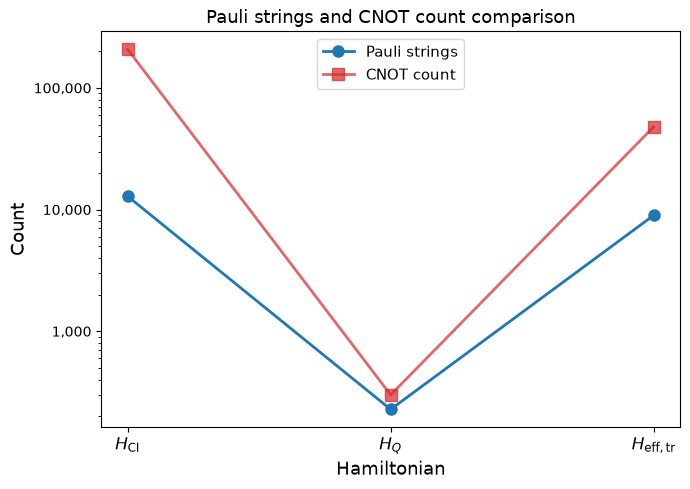

In [14]:
cnots = [tot_cnots_ci, cnot_q, cnots_bw]
print(cnots[0], cnots[1], cnots[2])
pauli_strings = [tot_pauli_strings_ci, pauli_strings_q, pauli_strings_bw]
print(pauli_strings[0], pauli_strings[1], pauli_strings[2])

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

labels = [r"$H_{\mathrm{CI}}$", r"$H_Q$", r"$H_{\mathrm{eff,tr}}$"]

fig, ax = plt.subplots(figsize=(7, 5))

color1 = "#1f77b4"
color2 = "#d62728"

ax.plot(
    labels,
    pauli_strings,
    marker="o",
    color=color1,
    linewidth=2,
    markersize=8,
    label="Pauli strings",
)
ax.plot(
    labels,
    cnots,
    marker="s",
    color=color2,
    linewidth=2,
    markersize=8,
    label="CNOT count",
    alpha=0.7,
)

ax.set_yscale("log")
ax.set_ylabel("Count", fontsize=13)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlabel("Hamiltonian", fontsize=13)
ax.tick_params(axis="x", labelsize=12)
ax.legend(loc="upper center", fontsize=11)

plt.title("Pauli strings and CNOT count comparison", fontsize=13)
plt.tight_layout()
plt.show()